In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/playground-series-s6e7/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e7/train.csv
/kaggle/input/competitions/playground-series-s6e7/test.csv


# **1. ➡️ EDA Steps**

# Setup & Data Loading 

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings
warnings.filterwarnings("ignore")
plt.rcParams['figure.figsize']=[12,6]

In [3]:
df=pd.read_csv("/kaggle/input/competitions/playground-series-s6e7/train.csv")
test=pd.read_csv("/kaggle/input/competitions/playground-series-s6e7/test.csv")
ss=pd.read_csv("/kaggle/input/competitions/playground-series-s6e7/sample_submission.csv")

In [4]:
df.duplicated().sum() 

np.int64(0)

In [5]:
df['id'].duplicated().sum() 

np.int64(0)

# Basic Dimensions & Feature classification 
* No. of row and columns in train dataset and test dataset
* first five rows of train and test dataset
* columns name in train dataset 

In [6]:
print(f'shape of train dataset : {df.shape}')

shape of train dataset : (690088, 15)


In [7]:
print(f'shape of test dataset :{test.shape}')

shape of test dataset :(295753, 14)


In [8]:
print(f'Train columns name : {df.columns.tolist()}') 

Train columns name : ['id', 'health_condition', 'sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake', 'diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']


In [9]:
numerical_cols=df.select_dtypes(include='number').columns.tolist()
cat_cols=df.select_dtypes(include='object').columns.tolist()
print(f'numeric_columns:{numerical_cols} ')
print("==================================================================================")
print(f'cat_columns:{cat_cols} ')

numeric_columns:['id', 'sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake'] 
cat_columns:['health_condition', 'diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender'] 


In [10]:
df.head()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


# Understanding The Features 
- **Numerical-** `sleep_duration`,`heart_rate`,`bmi`,`calorie_expenditure`,`step_count`, `exercise_duration`,`water_intake`
- **Categorical-** `diet_type`,`stress_level`,`sleep_quality`, `physical_activity_level`,`smoking_alcohol`,`gender`
- **Target Variable-** `health_condition`

In [11]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  object 
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  object 
 10  stress_level             607277 non-null  object 
 11  sleep_quality            631757 non-null  object 
 12  physical_activity_level  653467 non-null  object 
 13  smoking_alcohol          661506 non-null  object 
 14  gend

In [12]:
num_cols= ['sleep_duration','heart_rate','bmi','calorie_expenditure','step_count','exercise_duration','water_intake']
for col in num_cols:
    print(f'{col} no of unique value {df[col].nunique()}')
    print("================================================")
    print(f'{col} no of null  value {df[col].isna().sum()}')
    print("================================================")

    
    

sleep_duration no of unique value 701
sleep_duration no of null  value 75999
heart_rate no of unique value 537
heart_rate no of null  value 7833
bmi no of unique value 1596
bmi no of null  value 13898
calorie_expenditure no of unique value 2101
calorie_expenditure no of null  value 52853
step_count no of unique value 12807
step_count no of null  value 13916
exercise_duration no of unique value 856
exercise_duration no of null  value 6901
water_intake no of unique value 400
water_intake no of null  value 43477


In [13]:
cat_cols=['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender'] 
for col in cat_cols:
    print(f'{col} no of unique value {df[col].nunique()}')
    print("================================================")
    print(f'{col} no of null  value {df[col].isna().sum()}')
    print("================================================")
    print(f'{col} no of  value count {df[col].value_counts()}')
    print("================================================")

diet_type no of unique value 3
diet_type no of null  value 6901
diet_type no of  value count diet_type
veg         231432
balanced    226888
non-veg     224867
Name: count, dtype: int64
stress_level no of unique value 3
stress_level no of null  value 82811
stress_level no of  value count stress_level
medium    261819
high      177750
low       167708
Name: count, dtype: int64
sleep_quality no of unique value 3
sleep_quality no of null  value 58331
sleep_quality no of  value count sleep_quality
average    213948
poor       212166
good       205643
Name: count, dtype: int64
physical_activity_level no of unique value 3
physical_activity_level no of null  value 36621
physical_activity_level no of  value count physical_activity_level
moderate     221041
sedentary    219784
active       212642
Name: count, dtype: int64
smoking_alcohol no of unique value 3
smoking_alcohol no of null  value 28582
smoking_alcohol no of  value count smoking_alcohol
yes           223730
no            219791
occas

In [14]:
missing = pd.DataFrame({
    "Columns":df.columns,
    "Missing_Count": df.isnull().sum(),
    "Missing_Percent": df.isnull().mean() * 100
})

print(missing.sort_values("Missing_Percent", ascending=False))

                                         Columns  Missing_Count  \
stress_level                        stress_level          82811   
sleep_duration                    sleep_duration          75999   
sleep_quality                      sleep_quality          58331   
calorie_expenditure          calorie_expenditure          52853   
water_intake                        water_intake          43477   
physical_activity_level  physical_activity_level          36621   
smoking_alcohol                  smoking_alcohol          28582   
gender                                    gender          21373   
step_count                            step_count          13916   
bmi                                          bmi          13898   
heart_rate                            heart_rate           7833   
diet_type                              diet_type           6901   
exercise_duration              exercise_duration           6901   
id                                            id              

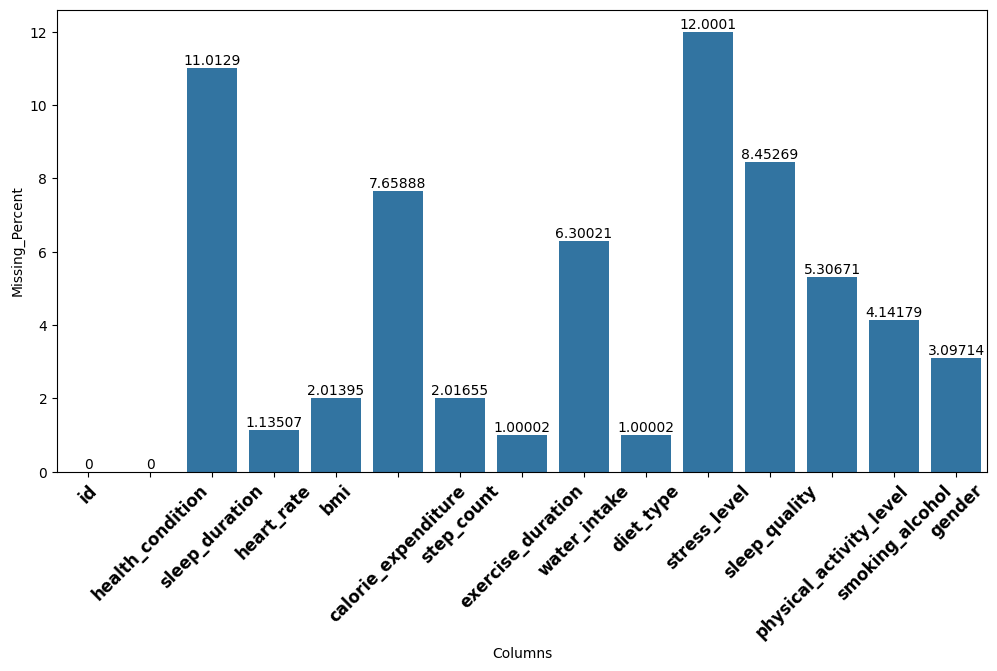

In [15]:
ax=sns.barplot(data=missing,x='Columns',y='Missing_Percent') 
ax.bar_label(ax.containers[0])
plt.xticks(rotation=45, fontsize=12, fontweight="bold")
plt.show()

# Data Visualization

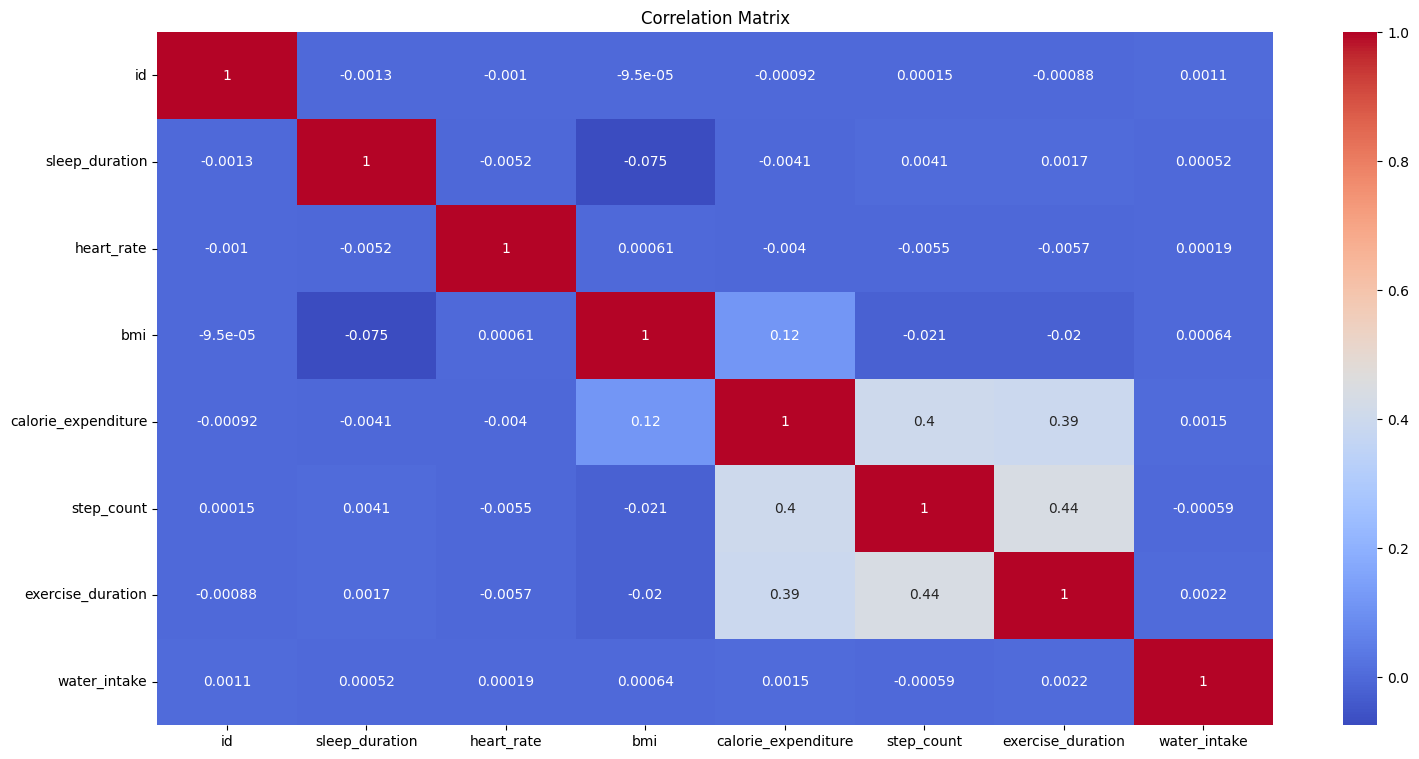

In [16]:
plt.figure(figsize=(18,9))
sns.heatmap(data=df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


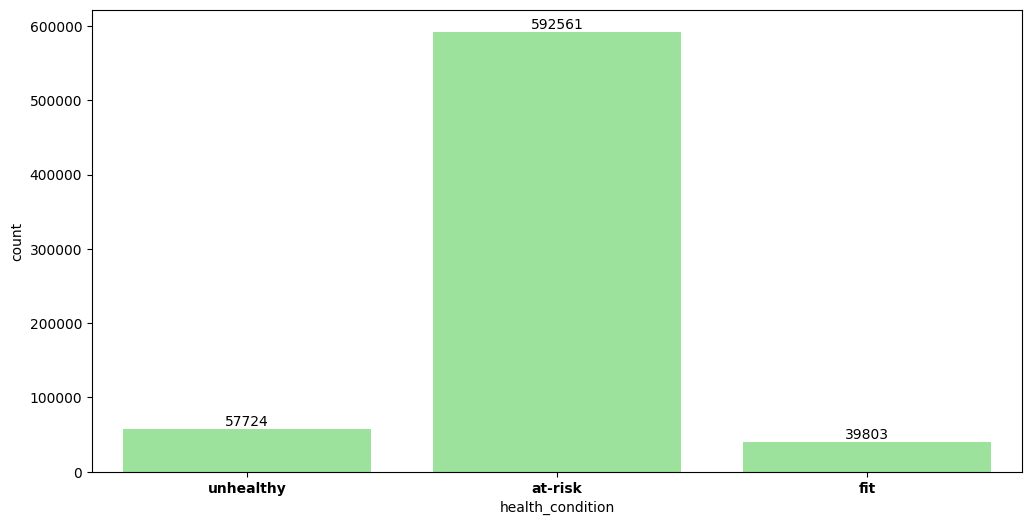

In [17]:
#target column value count
plt.figure(figsize=(12,6))
ax=sns.countplot(data=df,x='health_condition',color='lightgreen')
ax.bar_label(ax.containers[0])
plt.xticks(fontweight='bold')
plt.show()  

 Count plot graph of diet_type


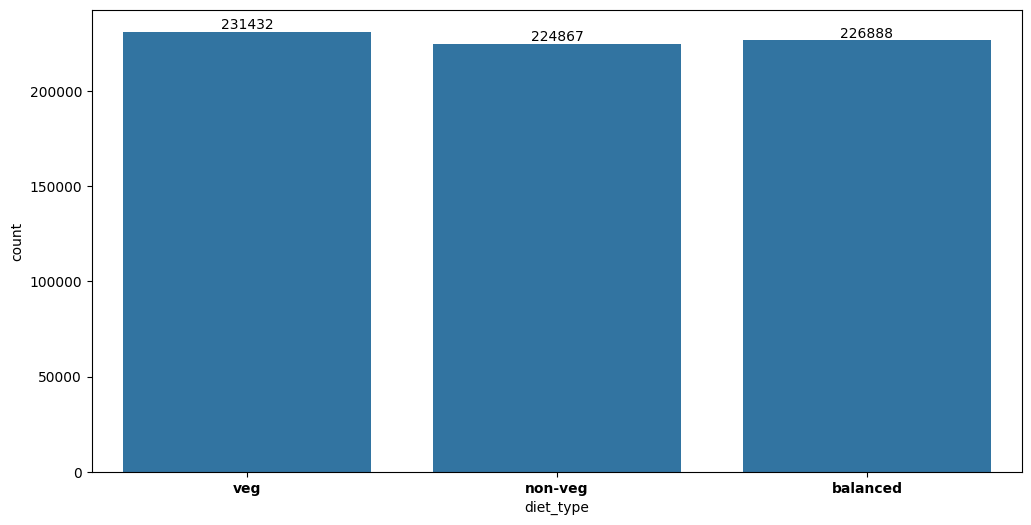

 Count plot graph of stress_level


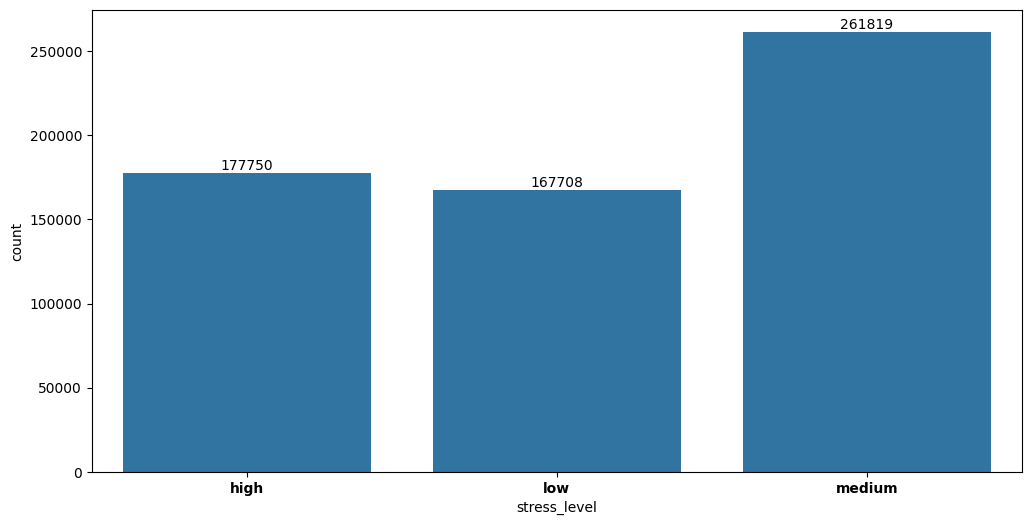

 Count plot graph of sleep_quality


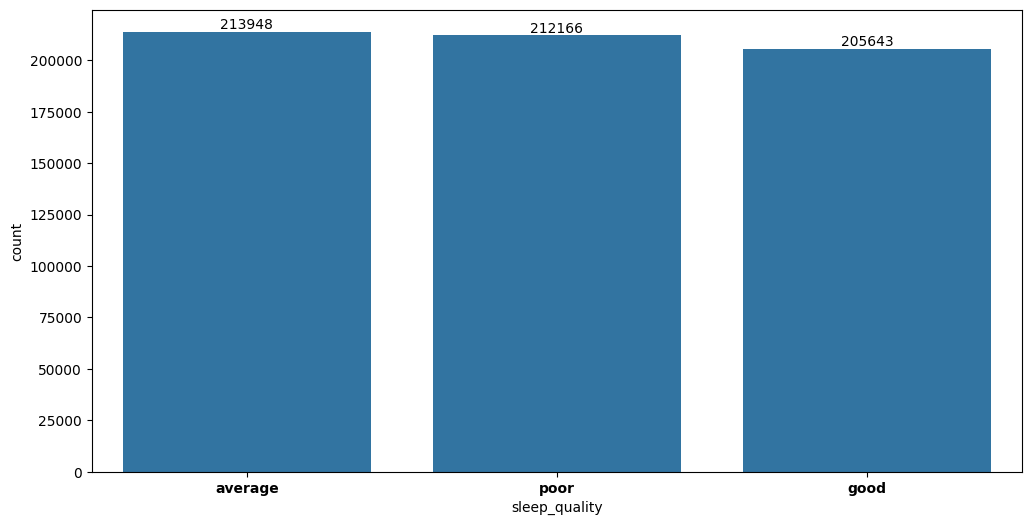

 Count plot graph of physical_activity_level


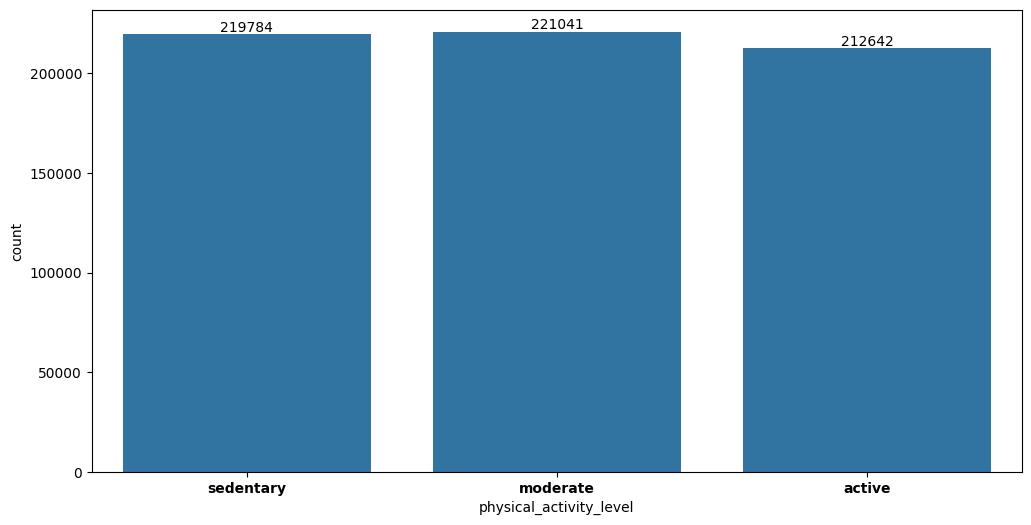

 Count plot graph of smoking_alcohol


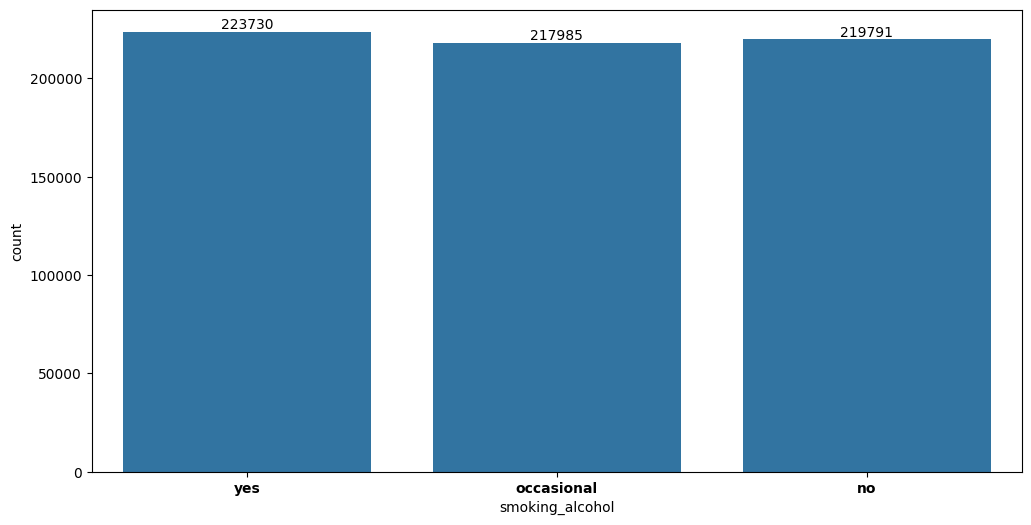

 Count plot graph of gender


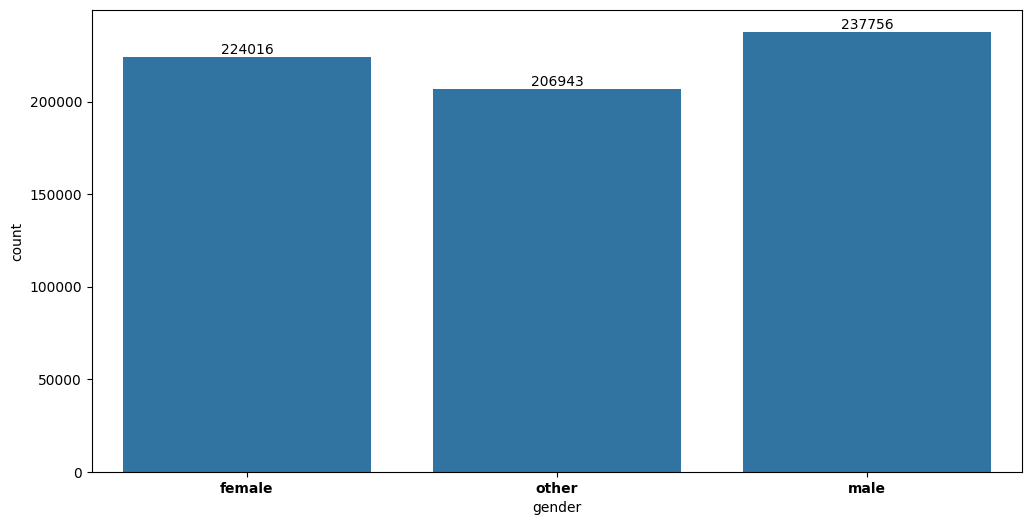

In [18]:
for x in cat_cols:
    print(f' Count plot graph of {x}')
    ax=sns.countplot(data=df,x=x)
    ax.bar_label(ax.containers[0])
    plt.xticks(fontweight='bold')
    plt.show() 
    print("===============================================================================")
    


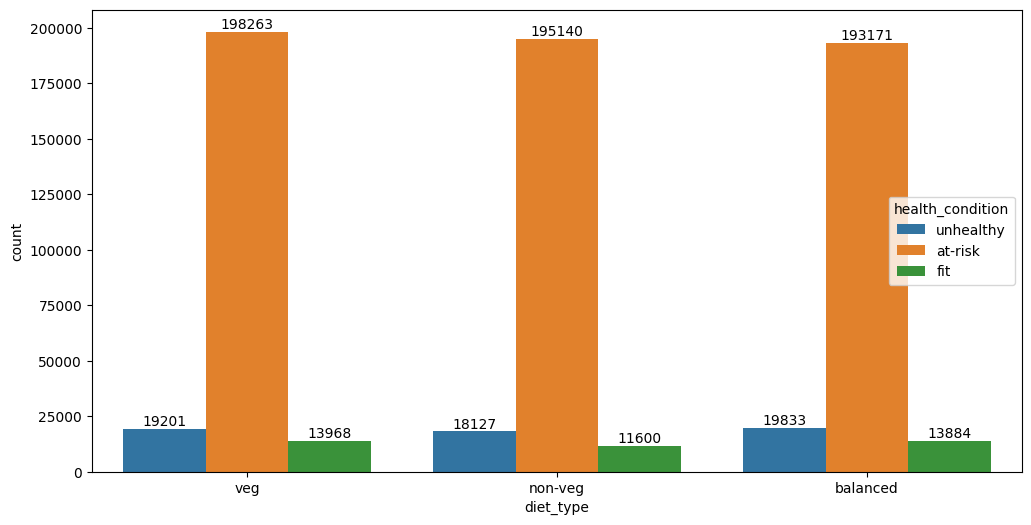

In [19]:
# count graph of  health condition the basis of  diet type
ax=sns.countplot(data=df,x="diet_type",hue="health_condition")
for container in ax.containers:
    ax.bar_label(container)
plt.show() 


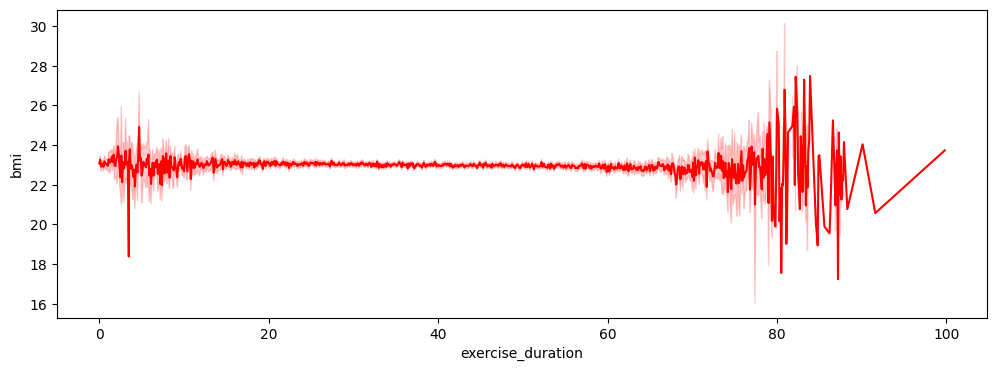

In [20]:
plt.figure(figsize=(12,4))
sns.lineplot(data=df,x="exercise_duration",y="bmi",color='red')
plt.show() 

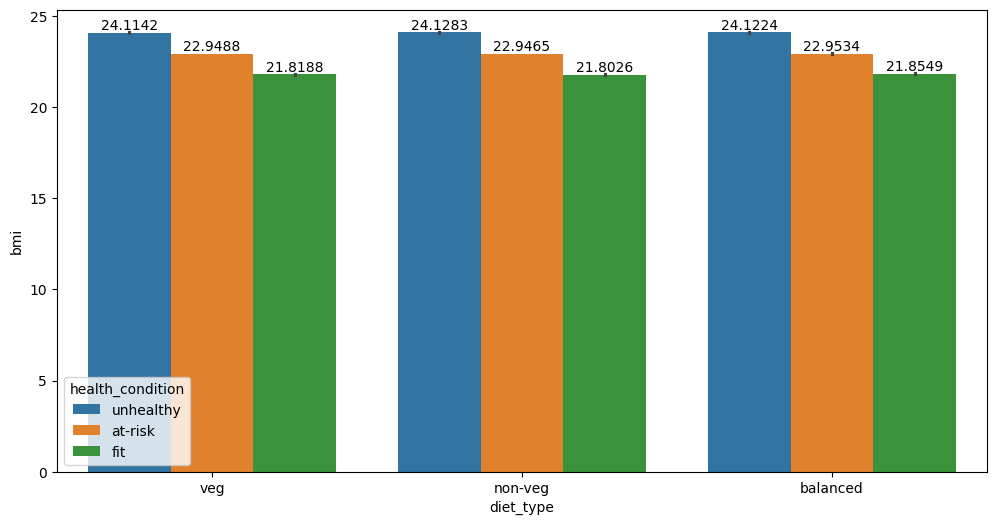

In [21]:
ax=sns.barplot(data=df,x="diet_type",y="bmi",hue="health_condition")
for container in ax.containers:
    ax.bar_label(container)
plt.show()

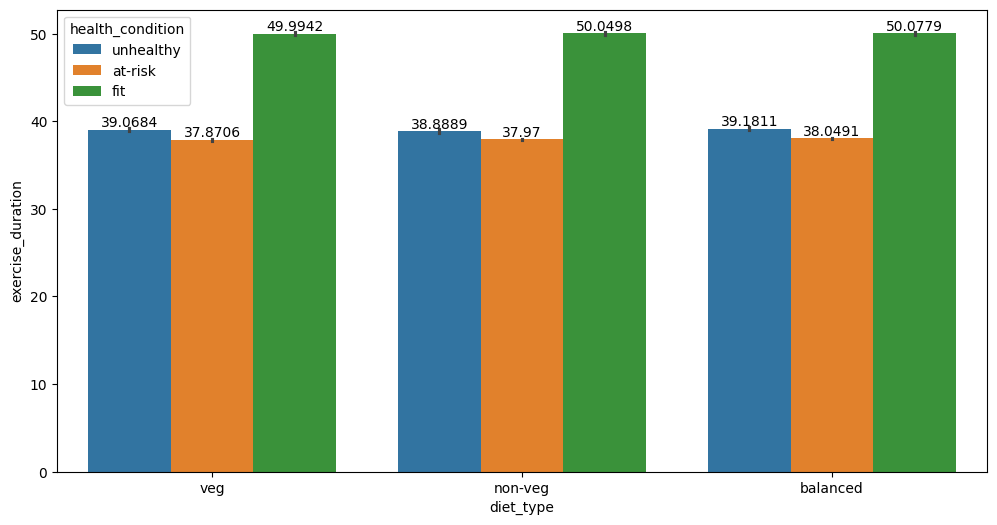

In [22]:
a=sns.barplot(data=df,x="diet_type",y="exercise_duration",hue="health_condition")
for container in a.containers:
    a.bar_label(container)
plt.show()

#  Descriptive Statistics
- **big gap between  mean and median(50%) - Skewed distribution/outlier present**
- **Very low std → constant column, low predictive value**


In [23]:
df.describe().T 

,count,mean,std,min,25%,50%,75%,max
id,690088.0,345043.500000,199211.390620,0.0,172521.75,345043.50,517565.25,690087.00
sleep_duration,614089.0,6.992597,1.215407,3.0,6.16,6.99,7.81,10.00
heart_rate,682255.0,75.096504,8.175106,50.0,69.40,75.10,80.70,107.70
bmi,676190.0,22.984925,2.481787,16.0,21.32,22.99,24.66,34.82
calorie_expenditure,637235.0,2226.084931,347.532098,1200.0,2053.00,2241.00,2456.00,3580.00
step_count,676172.0,8615.953050,3929.399831,1002.0,5389.00,8856.00,12114.00,14999.00
exercise_duration,683187.0,38.751456,14.742189,0.0,29.20,39.40,49.40,99.80
water_intake,646611.0,2.188542,0.518489,0.5,1.84,2.17,2.50,4.72


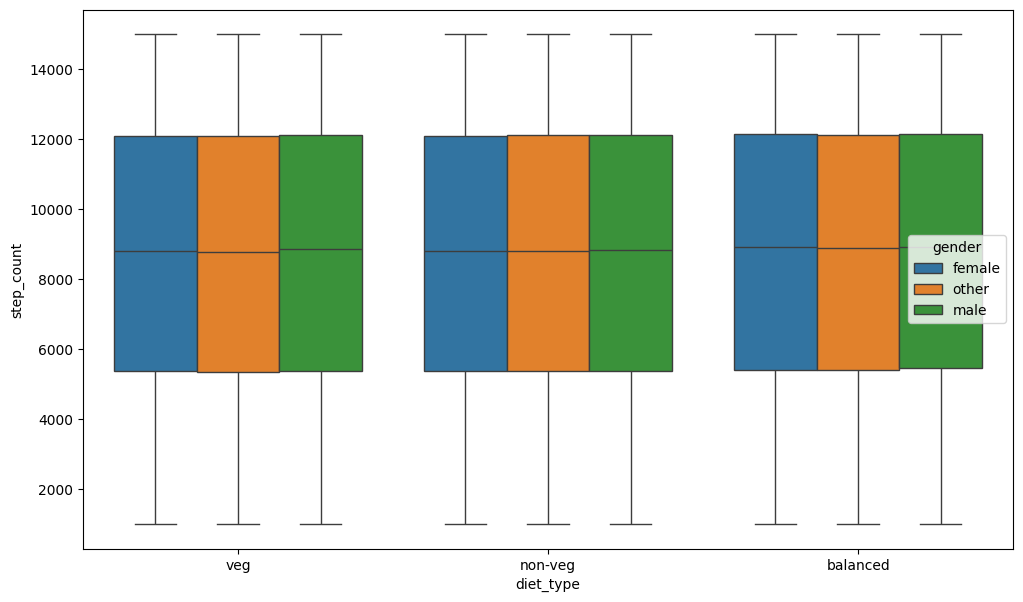

In [24]:
plt.figure(figsize=(12,7))
sns.boxplot(data=df,hue='gender',y='step_count',x='diet_type')
plt.show()

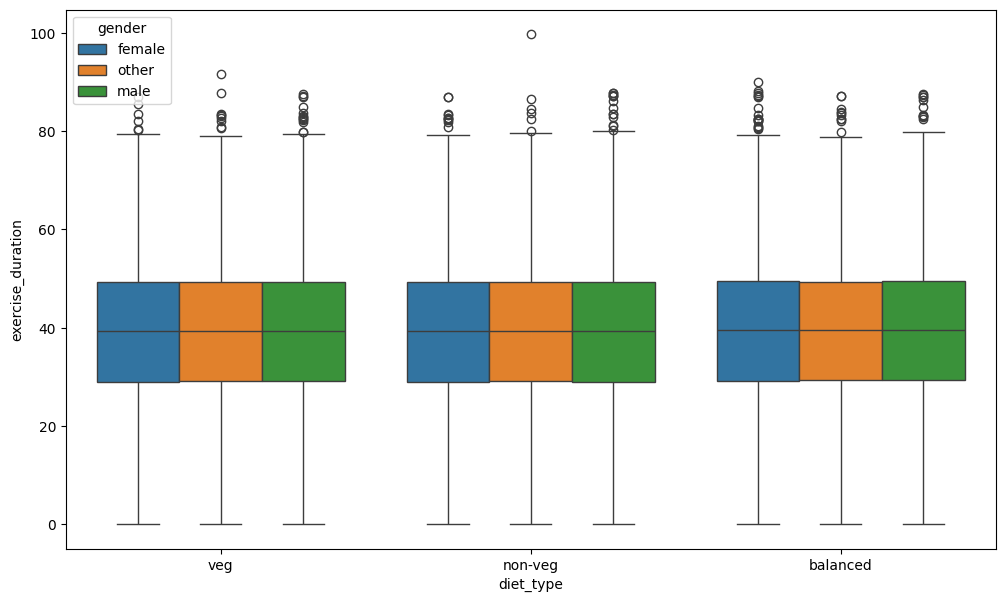

In [25]:
plt.figure(figsize=(12,7))
sns.boxplot(data=df,hue='gender',y='exercise_duration',x='diet_type')
plt.show()

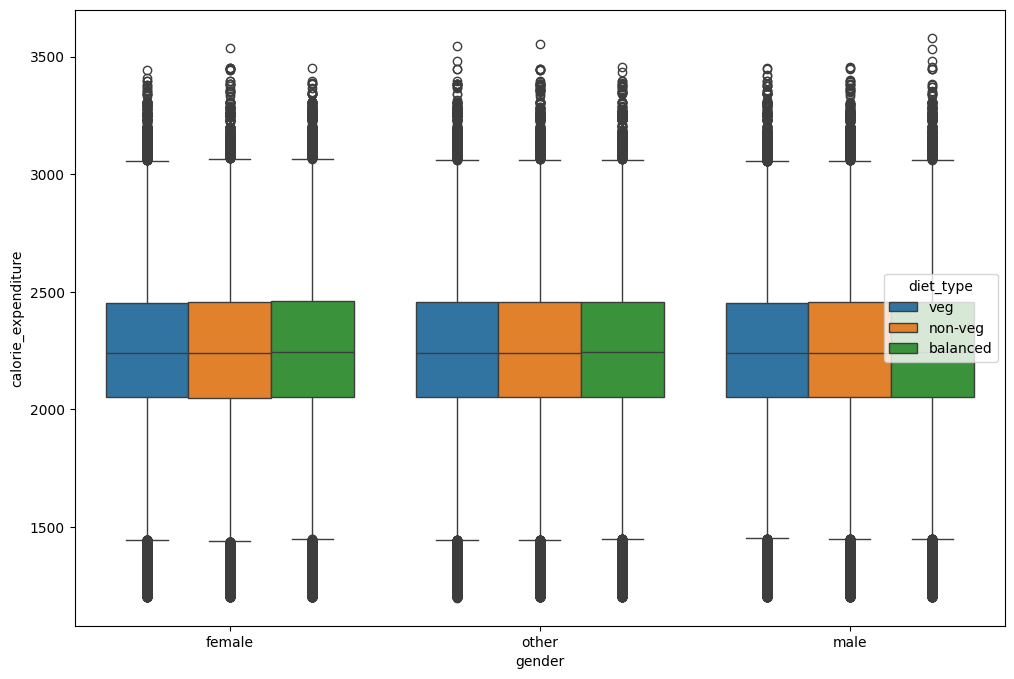

In [26]:
plt.figure(figsize=(12,8))
sns.boxplot(data=df,x='gender',y='calorie_expenditure',hue='diet_type')
plt.show() 

# 2.  Feature Engineering 
**Creating  new features**
1. water_intake_level
2. calorie_level
3. heart_rate_level
4. bmi_level

In [27]:
df.head()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


In [28]:
df["water_intake_level"] = pd.cut(
    df["water_intake"],
    bins=[-float("inf"), 1.5, 2.5, float("inf")],
    labels=["Bad", "Average", "Good"]
)
test["water_intake_level"] = pd.cut(
    test["water_intake"],
    bins=[-float("inf"), 1.5, 2.5, float("inf")],
    labels=["Bad", "Average", "Good"]
)

In [29]:
df["calorie_level"] = pd.cut(
    df["calorie_expenditure"],
    bins=[-float("inf"), 1800, 2500, float("inf")],
    labels=["Low", "Average", "High"]
)
test["calorie_level"] = pd.cut(
    test["calorie_expenditure"],
    bins=[-float("inf"), 1800, 2500, float("inf")],
    labels=["Low", "Average", "High"]
) 

In [30]:
df["heart_rate_level"] = pd.cut(
    df["heart_rate"],
    bins=[-float("inf"), 60, 100, float("inf")],
    labels=["Low", "Normal", "High"]
)
test["heart_rate_level"] = pd.cut(
    test["heart_rate"],
    bins=[-float("inf"), 60, 100, float("inf")],
    labels=["Low", "Normal", "High"]
)

In [31]:
df["bmi_level"] = pd.cut(
    df["bmi"],
    bins=[-float("inf"), 18.5, 25, 30, float("inf")],
    labels=["Underweight", "Normal", "Overweight", "Obese"]
)
test["bmi_level"] = pd.cut(
    test["bmi"],
    bins=[-float("inf"), 18.5, 25, 30, float("inf")],
    labels=["Underweight", "Normal", "Overweight", "Obese"]
) 

In [32]:
df.head() 

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender,water_intake_level,calorie_level,heart_rate_level,bmi_level
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female,Average,Average,Normal,Overweight
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other,Bad,Average,Normal,Overweight
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male,Average,High,Normal,Normal
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female,Average,High,Normal,Normal
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male,Average,High,Normal,Overweight


# 3. Train-test split 

In [33]:
y=df['health_condition']
x=df.drop('health_condition',axis=1)


In [34]:
from sklearn.model_selection import train_test_split  
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)   

# 4 .Data Preprocessing &  Pipeline 
- **missing value handling - simple imputer**
- **data scaling - StandardScaler(numeric col)**
- **Encoding-(onehot -- unique value max 3 in categorical columns )**


In [35]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline 


In [36]:
num_pipe=Pipeline([
    ('SimpleImputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
]) 

In [37]:
cat_pipe=Pipeline([
    ('simpleImputer',SimpleImputer(strategy='constant',fill_value='missing')),
    ('encoder',OneHotEncoder()) 
])

In [38]:
num_cols= ['sleep_duration','step_count','exercise_duration','water_intake','bmi','calorie_expenditure','heart_rate']
cat_cols=['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender' ,'water_intake_level','bmi_level','calorie_level','heart_rate_level'] 


In [39]:
preprocessor=ColumnTransformer([
    ('numeric',num_pipe,num_cols),
    ('cat',cat_pipe,cat_cols)
],remainder="drop")


# 5 .Model Training 

In [40]:
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,classification_report
from sklearn.pipeline import Pipeline

In [41]:
cat_model = CatBoostClassifier(
    auto_class_weights="Balanced",
    verbose=False,
    random_seed=42
) 
c_model = Pipeline([ 
        ('preprocessor', preprocessor),
        ('model',cat_model)
]) 
c_model.fit(x_train,y_train) 


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('SimpleImputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['sleep_duration',
                                                   'step_count',
                                                   'exercise_duration',
                                                   'water_intake', 'bmi',
                                                   'calorie_expenditure',
                                                   'heart_rate']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleImputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder())]),
                                                  ['diet_type', 'stress_level',
                                                   'sleep_quality',
                                                   'physical_activity_level',
                                                   'smoking_alcohol', 'gender',
                                                   'water_intake_level',
                                                   'bmi_level', 'calorie_level',
                                                   'heart_rate_level'])])),
                ('model',
                 CatBoostClassifier(auto_class_weights='Balanced', random_seed=42, verbose=False))])

In [42]:
c_model.score(x_test,y_test)

np.float64(0.9390876552333753)

In [43]:
pred = c_model.predict(x_test) 
print(classification_report(y_test, pred)) 

              precision    recall  f1-score   support

     at-risk       0.99      0.94      0.96    118512
         fit       0.74      0.95      0.83      7961
   unhealthy       0.69      0.96      0.80     11545

    accuracy                           0.94    138018
   macro avg       0.81      0.95      0.87    138018
weighted avg       0.95      0.94      0.94    138018



In [44]:
lgbm_model = LGBMClassifier(
    class_weight="balanced",
    random_state=42,
    verbosity=-1
)
l_model = Pipeline([ 
        ('preprocessor', preprocessor),
        ('model',lgbm_model)
]) 
l_model.fit(x_train,y_train) 

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('SimpleImputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['sleep_duration',
                                                   'step_count',
                                                   'exercise_duration',
                                                   'water_intake', 'bmi',
                                                   'calorie_expenditure',
                                                   'heart_rate']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleImputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder())]),
                                                  ['diet_type', 'stress_level',
                                                   'sleep_quality',
                                                   'physical_activity_level',
                                                   'smoking_alcohol', 'gender',
                                                   'water_intake_level',
                                                   'bmi_level', 'calorie_level',
                                                   'heart_rate_level'])])),
                ('model',
                 LGBMClassifier(class_weight='balanced', random_state=42,
                                verbosity=-1))])

In [45]:
pred = l_model.predict(x_test) 
print(classification_report(y_test, pred))  

              precision    recall  f1-score   support

     at-risk       0.99      0.93      0.96    118512
         fit       0.73      0.95      0.83      7961
   unhealthy       0.68      0.97      0.80     11545

    accuracy                           0.94    138018
   macro avg       0.80      0.95      0.86    138018
weighted avg       0.95      0.94      0.94    138018



# **6 .Final Model**

In [46]:
from lightgbm import LGBMClassifier 
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score,classification_report



KF = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = []
 
for fold, (train_idx, val_idx) in enumerate(KF.split(x, y)):

    x_train = x.iloc[train_idx]
    x_val = x.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx] 

    model = Pipeline([ 
        ('preprocessor', preprocessor),
        ('classifier', LGBMClassifier(
            n_estimators=400,           
            learning_rate=0.03,        
            max_depth=8,                
            class_weight='balanced',    # Forces to care about rare health conditions
            random_state=42 + fold,
            verbose=-1                 
        ))   
    ])

    model.fit(x_train, y_train)

    pred = model.predict(x_val)

    score = accuracy_score(y_val, pred)
   
    scores.append(score) 
    print(classification_report(y_val, pred))
    print("===================")
    print(f"Fold {fold + 1}: {score:.4f}") 

print("Mean CV:", np.mean(scores))


              precision    recall  f1-score   support

     at-risk       0.99      0.94      0.96    118512
         fit       0.73      0.95      0.83      7961
   unhealthy       0.69      0.96      0.81     11545

    accuracy                           0.94    138018
   macro avg       0.80      0.95      0.86    138018
weighted avg       0.95      0.94      0.94    138018

Fold 1: 0.9385
              precision    recall  f1-score   support

     at-risk       0.99      0.93      0.96    118512
         fit       0.73      0.95      0.83      7961
   unhealthy       0.69      0.97      0.80     11545

    accuracy                           0.94    138018
   macro avg       0.81      0.95      0.87    138018
weighted avg       0.95      0.94      0.94    138018

Fold 2: 0.9385
              precision    recall  f1-score   support

     at-risk       0.99      0.93      0.96    118512
         fit       0.72      0.95      0.82      7961
   unhealthy       0.69      0.96      0.80  

In [47]:
pred = model.predict(x_test) 
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

     at-risk       0.99      0.94      0.96    118512
         fit       0.74      0.95      0.83      7961
   unhealthy       0.69      0.97      0.81     11545

    accuracy                           0.94    138018
   macro avg       0.81      0.95      0.87    138018
weighted avg       0.95      0.94      0.94    138018



# 7. Model Evaluation 

In [48]:
y_pred = model.predict(x_test) 
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
print("\n\nAccuracy: ", accuracy_score(y_test, y_pred))
print("\n\nClassification report: ")
print(classification_report(y_test, y_pred))

print("\n\nConfusion matrix: ")
print(confusion_matrix(y_test, y_pred)) 



Accuracy:  0.9391601095509281


Classification report: 
              precision    recall  f1-score   support

     at-risk       0.99      0.94      0.96    118512
         fit       0.74      0.95      0.83      7961
   unhealthy       0.69      0.97      0.81     11545

    accuracy                           0.94    138018
   macro avg       0.81      0.95      0.87    138018
weighted avg       0.95      0.94      0.94    138018



Confusion matrix: 
[[110889   2656   4967]
 [   339   7570     52]
 [   336     47  11162]]


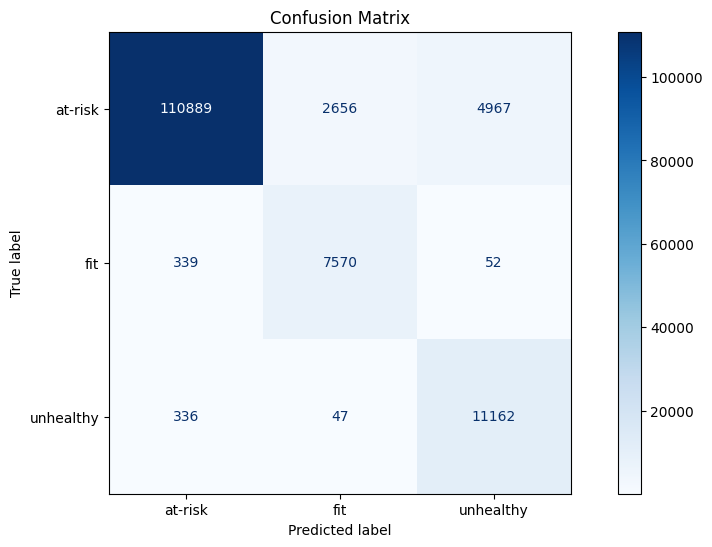

In [49]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay 

# confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

# 8 .Submission 

In [50]:
prediction=model.predict(test)
prediction 

array(['unhealthy', 'unhealthy', 'at-risk', ..., 'unhealthy', 'at-risk',
       'unhealthy'], dtype=object)

In [51]:
submission = pd.DataFrame({
    "id": test["id"],
    "health_condition": prediction    
})

submission.to_csv("submission.csv", index=False)

print("New submission created.")   

New submission created.
